In [3]:
import numpy as np
import pandas as pd
import tsfresh as ts
from sklearn import preprocessing
from tqdm import tqdm
from feature_engine.selection import DropConstantFeatures, DropDuplicateFeatures, DropCorrelatedFeatures, SmartCorrelatedSelection, SelectBySingleFeaturePerformance
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

### Step 1: Load Data in from Step Parsing

In [4]:
fe = []
lablist = []
speed_labels = []
angle_labels = []
for sj in range(2, 16):
    csv_file_path = f'./steps_data_new/sj{sj}.csv'
    df = pd.read_csv(csv_file_path)
    df = df[~df['Speed'].str.contains('warm_up')]
    df = df[~df['Speed'].str.contains('cool_down')]
    labels = df.groupby('Step')['Combined'].apply(list)
    labels = [sublist[0] for sublist in labels]
    speeds =[]
    angles = []
    for label in labels:
        speed, angle = label.split('_')
        speeds.append(speed)
        angles.append(int(angle))
    le = LabelEncoder()
    speed_labels.append(le.fit_transform(speeds))
    angle_labels.append(le.fit_transform(angles))
    l2 = preprocessing.LabelEncoder()
    l2.fit(labels)
    labs = l2.transform(labels)
    #labs = [x // 2 for x in labs]
    lablist.append(labs)
    le = preprocessing.LabelEncoder()
    le.fit(df.Step)
    df['Step'] = le.transform(df.Step)
    df = df.drop(columns = ['Unnamed: 0', 'Forefoot', 'Midfoot', 'Heel', 'Total', 'AT_loading', 'Speed', 'Incline', 'Combined'])
    extracted_features = ts.extract_features(df, column_id = 'Step', column_sort = 'Time')
    fe.append(extracted_features)

Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 50/50 [00:09<00:00,  5.19it/s]


### Step 2: Split Dataset into Training/Testing and remove NaN values

In [5]:
X_train = []
X_test  = []
Y_train = []
Y_test  = []
S_train = []
S_test  = []
A_train = []
A_test  = []

from collections import Counter
from sklearn.preprocessing import StandardScaler

for i in tqdm(range(len(fe))):
    rem = []
    X_ = fe[i]
    for j in range(X_.columns.shape[0]):
        num_class = np.unique(X_.iloc[:,j]).shape[0]
        if num_class <= 2 or np.where(X_.iloc[:,j].isna())[0].shape[0] != 0 or np.sum(np.isinf(X_.iloc[:,j])) > 0:
            rem.append(X_.columns[j])
    y = np.array(lablist[i])
    counts = Counter(y)
    mask = np.array([counts[label]> 1 for label in y])
    X_f = X_[mask]
    y_f = y[mask]
    s = speed_labels[i][mask]
    a = angle_labels[i][mask]
    new_feat = X_f.drop(columns = rem)
    X_train_temp, X_test_temp, Y_train_temp, Y_test_temp,S_train_temp,S_test_temp,A_train_temp,A_test_temp = train_test_split(new_feat, y_f, s, a, stratify = y_f, test_size = 0.2, random_state = 42)
    X_train.append(X_train_temp)
    X_test.append(X_test_temp)
    Y_train.append(Y_train_temp)
    Y_test.append(Y_test_temp)
    S_train.append(S_train_temp)
    S_test.append(S_test_temp)
    A_train.append(A_train_temp)
    A_test.append(A_test_temp)

for i in range(len(X_train)):
    scaler = StandardScaler()
    X_train[i] = scaler.fit_transform(X_train[i])
    X_test[i] = scaler.transform(X_test[i])
    


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:08<00:00,  1.74it/s]


### Step 3: Remove Overly Correlated Features using Feature Engine's Smart Correlated Selection

In [6]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [7]:
est = SVC(random_state = 0)
kfold = KFold(n_splits=5, random_state=0, shuffle = True)
feats = []
X_temp = []
T_temp = []
X_train_uni = []
X_test_uni  = []
for i in tqdm(range(len(X_train))):
    X = X_train[i]
    Y = Y_train[i]
    tr = []
    tr = SmartCorrelatedSelection(selection_method = 'model_performance',estimator = est,cv = kfold)
    X2 = tr.fit_transform(X, Y)
    test_temp = tr.transform(X_test[i])
    print(X2.shape)
    X_temp.append(X2)
    T_temp.append(test_temp)


  7%|█████▉                                                                             | 1/14 [00:22<04:55, 22.75s/it]

(468, 242)


 14%|███████████▊                                                                       | 2/14 [00:51<04:54, 24.52s/it]

(532, 279)


 21%|█████████████████▊                                                                 | 3/14 [01:13<04:21, 23.73s/it]

...

(418, 421)


 93%|████████████████████████████████████████████████████████████████████████████▏     | 13/14 [04:47<00:21, 21.28s/it]

(177, 207)


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [05:07<00:00, 21.93s/it]

(187, 329)


### Step 4: Determine optimal K for each patient's model using standard error method

In [8]:
k_grid = [10, 20, 30, 40, 50, 60, 70, 80]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = "accuracy"

k_chosen = []
cv_chosen = []

for i in range(len(X_temp)):
    Xtrain = X_temp[i]
    Xtest  = T_temp[i]
    y_train = Y_train[i]
    y_test = Y_test[i]
    results = []
    for k in k_grid:
        pipeline = Pipeline([
            ("select", SelectKBest(score_func=f_classif, k=k)),
            ("model", RandomForestClassifier(random_state = 1))
        ])
    
        scores = cross_val_score(pipeline, Xtrain, y_train,
                             cv=cv, scoring=scoring)
    
        mean_score = np.mean(scores)
        std_error = np.std(scores) / np.sqrt(len(scores))
    
        results.append({
            "k": k,
            "mean_score": mean_score,
            "std_error": std_error
        })

    results_df = pd.DataFrame(results)



    best_row = results_df.loc[results_df["mean_score"].idxmax()]
    best_score = best_row["mean_score"]
    best_se = best_row["std_error"]


    threshold = best_score - best_se


    eligible_models = results_df[results_df["mean_score"] >= threshold]
    selected_k = eligible_models["k"].min()
    k_chosen.append(selected_k)
    cv_chosen.append(best_score)
    print("Model # ", i)
    print("Best CV score:", best_score)
    print("Standard Error:", best_se)
    print("Threshold (1-SE rule):", threshold)
    print("Selected k:", selected_k)
    print("")

Model #  0
Best CV score: 0.705216197666438
Standard Error: 0.01848943602729383
Threshold (1-SE rule): 0.6867267616391441
Selected k: 60

Model #  1
Best CV score: 0.7237700581907953
Standard Error: 0.017625796203784055
Threshold (1-SE rule): 0.7061442619870113
Selected k: 50

Model #  2
Best CV score: 0.7170506912442395
Standard Error: 0.013314703089239547
Threshold (1-SE rule): 0.7037359881549999
Selected k: 50

Model #  3
Best CV score: 0.6836725463591135
Standard Error: 0.02238960380989653
Threshold (1-SE rule): 0.6612829425492169
Selected k: 50

Model #  4
Best CV score: 0.5470985155195682
Standard Error: 0.009643978130771348
Threshold (1-SE rule): 0.5374545373887969
Selected k: 60

Model #  5
Best CV score: 0.7653082549634274
Standard Error: 0.015502078937992146
Threshold (1-SE rule): 0.7498061760254352
Selected k: 40

Model #  6
Best CV score: 0.6560776302349336
Standard Error: 0.010531694177166807
Threshold (1-SE rule): 0.6455459360577668
Selected k: 80

Model #  7
Best CV scor

### Step 5: Evaluate Model Performance for each patient

In [25]:
selected_feature_sets = []
a_list = []
p_list = []
r_list = []
f1_list = []
t_list = []
angle_list = []
speed_list = []
t2_list = []
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, top_k_accuracy_score


for i in range(len(X_temp)):
    X = X_temp[i]
    y = Y_train[i]
    k = k_chosen[i]
    T = T_temp[i]
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X, y)
    
    # Get selected feature names
    mask = selector.get_support()
    selected_features = X.columns[mask]
    
    selected_feature_sets.append(set(selected_features))
    
    X0 = selector.transform(X)
    T0 = selector.transform(T)
    rf = RandomForestClassifier(random_state = 1)
    clf = rf.fit(X0,y)
    y_pred = clf.predict(T0)
    y_score = clf.predict_proba(T0)
    t_list.append(top_k_accuracy_score(Y_test[i], y_score, k = 2))
    a_list.append(accuracy_score(Y_test[i], y_pred))
    t2_list.append(top_k_accuracy_score(Y_test[i], y_score, k = 3))
    p_list.append(precision_score(Y_test[i], y_pred, average = 'weighted'))
    r_list.append(recall_score(Y_test[i], y_pred, average = 'weighted'))
    f1_list.append(f1_score(Y_test[i], y_pred, average = None))
    
n = len(a_list)
indices = np.arange(n)




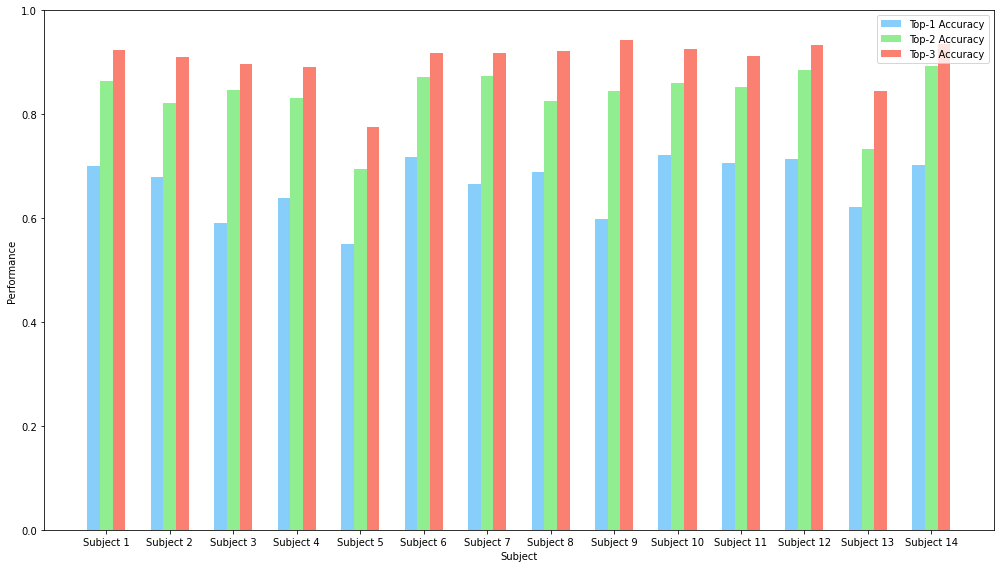

In [45]:
width = 0.2


plt.figure(figsize=(14,8))
plt.bar(indices - width, a_list, width=width, label='Top-1 Accuracy', color='lightskyblue')
plt.bar(indices, t_list, width=width, label='Top-2 Accuracy', color='lightgreen')
plt.bar(indices + width, t2_list, width=width, label='Top-3 Accuracy', color='salmon')


plt.xlabel('Subject')
plt.ylabel('Performance')
plt.xticks(indices, [f'Subject {i+1}' for i in range(len(a_list))])
plt.ylim(0,1)
plt.legend()

# Show the plot
plt.tight_layout()
plt.savefig('accuracycompare.png')
plt.show()

In [27]:
np.mean(np.array(a_list)), np.mean(np.array(t_list)), np.mean(np.array(t2_list))

(0.6641819352444625, 0.8355945122893305, 0.9036949613006089)

In [12]:
np.std(np.array(a_list)), np.std(np.array(t_list)), np.std(np.array(t2_list))

(0.05296628327273222, 0.05445088742385015, 0.042549302339912644)

In [13]:
np.median(np.array(a_list)), np.median(np.array(t_list)), np.median(np.array(t2_list))

(0.6842124329807274, 0.8495475113122172, 0.9185503685503686)

In [38]:
n = []
for i in range(len(fe)):
    n.append(fe[i].shape[0])

In [39]:
results = pd.DataFrame([n,a_list,t_list,t2_list,p_list,r_list])

In [41]:
results.T.to_csv('resultsdf.csv')

In [42]:
results.T

,0,1,2,3,4,5
0,585.0,0.700855,0.863248,0.923077,0.711717,0.700855
1,666.0,0.679104,0.820896,0.910448,0.677170,0.679104
2,389.0,0.589744,0.846154,0.897436,0.585409,0.589744
3,415.0,0.638554,0.831325,0.891566,0.652553,0.638554
4,241.0,0.551020,0.693878,0.775510,0.575316,0.551020
5,549.0,0.718182,0.872727,0.918182,0.709829,0.718182
6,553.0,0.666667,0.873874,0.918919,0.649198,0.666667
7,515.0,0.689320,0.825243,0.922330,0.733160,0.689320
8,609.0,0.598361,0.844262,0.942623,0.588622,0.598361
9,536.0,0.722222,0.861111,0.925926,0.748383,0.722222


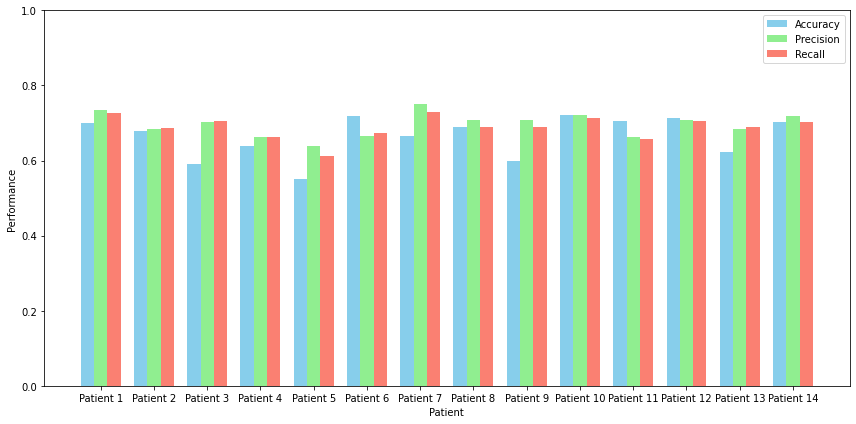

In [23]:
selected_feature_sets = []
a6_list = []
p6_list = []
r6_list = []
f1_list = []
t_list = []
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, top_k_accuracy_score


for i in range(len(X_temp)):
    X = X_temp[i]
    y = A_train[i]
    k = k_chosen[i]
    T = T_temp[i]
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X, y)
    
    # Get selected feature names
    mask = selector.get_support()
    selected_features = X.columns[mask]
    
    selected_feature_sets.append(set(selected_features))
    
    X0 = selector.transform(X)
    T0 = selector.transform(T)
    rf = RandomForestClassifier(random_state = 1)
    clf = rf.fit(X0,y)
    y_pred = clf.predict(T0)
    y_score = clf.predict_proba(T0)
    t_list.append(top_k_accuracy_score(A_test[i], y_score, k = 2))
    a6_list.append(accuracy_score(A_test[i], y_pred))
    p6_list.append(precision_score(A_test[i], y_pred, average = 'weighted'))
    r6_list.append(recall_score(A_test[i], y_pred, average = 'weighted'))
    f1_list.append(f1_score(A_test[i], y_pred, average = None))
    
n = len(a_list)
indices = np.arange(n)


width = 0.25


plt.figure(figsize=(12,6))
plt.bar(indices - width, a_list, width=width, label='Accuracy', color='skyblue')
plt.bar(indices, p6_list, width=width, label='Precision', color='lightgreen')
plt.bar(indices + width, r6_list, width=width, label='Recall', color='salmon')


plt.xlabel('Patient')
plt.ylabel('Performance')
plt.xticks(indices, [f'Patient {i+1}' for i in range(n)])
plt.ylim(0,1)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [18]:
np.mean(np.array(a6_list)), np.std(np.array(a6_list)), np.median(np.array(a6_list))

(0.6884994813163267, 0.029527166369565448, 0.6891046386192017)

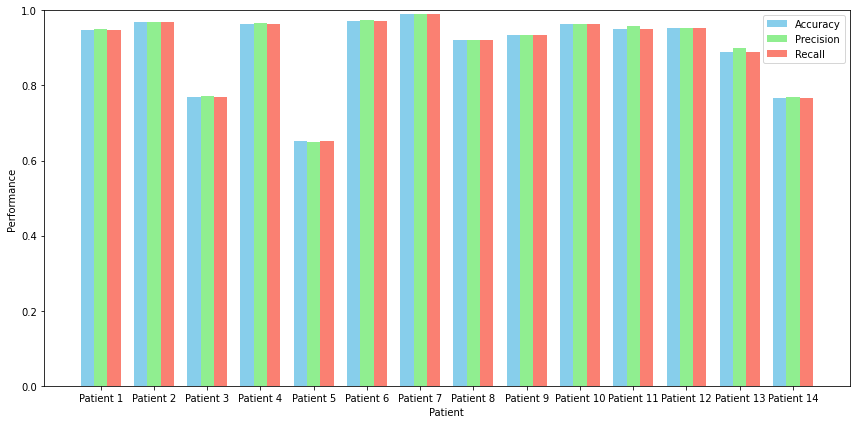

In [24]:
selected_feature_sets = []
a3_list = []
p3_list = []
r3_list = []
f1_list = []
t_list = []
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, top_k_accuracy_score


for i in range(len(X_temp)):
    X = X_temp[i]
    y = S_train[i]
    k = k_chosen[i]
    T = T_temp[i]
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X, y)
    
    # Get selected feature names
    mask = selector.get_support()
    selected_features = X.columns[mask]
    
    selected_feature_sets.append(set(selected_features))
    
    X0 = selector.transform(X)
    T0 = selector.transform(T)
    rf = RandomForestClassifier(random_state = 1)
    clf = rf.fit(X0,y)
    y_pred = clf.predict(T0)
    y_score = clf.predict_proba(T0)
    t_list.append(top_k_accuracy_score(S_test[i], y_score, k = 2))
    a3_list.append(accuracy_score(S_test[i], y_pred))
    p3_list.append(precision_score(S_test[i], y_pred, average = 'weighted'))
    r3_list.append(recall_score(S_test[i], y_pred, average = 'weighted'))
    f1_list.append(f1_score(S_test[i], y_pred, average = None))
    
n = len(a_list)
indices = np.arange(n)


width = 0.25


plt.figure(figsize=(12,6))
plt.bar(indices - width, a3_list, width=width, label='Accuracy', color='skyblue')
plt.bar(indices, p3_list, width=width, label='Precision', color='lightgreen')
plt.bar(indices + width, r3_list, width=width, label='Recall', color='salmon')


plt.xlabel('Patient')
plt.ylabel('Performance')
plt.xticks(indices, [f'Patient {i+1}' for i in range(n)])
plt.ylim(0,1)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [20]:
np.mean(np.array(a3_list)), np.std(np.array(a3_list)), np.median(np.array(a3_list))

(0.9033328465263303, 0.09708100039219511, 0.9498491704374057)

In [38]:
n = []
for i in range(len(fe)):
    n.append(fe[i].shape[0])

In [39]:
results = pd.DataFrame([n,a_list,t_list,t2_list,p_list,r_list])

In [41]:
results.T.to_csv('resultsdf.csv')

In [42]:
results.T

,0,1,2,3,4,5
0,585.0,0.700855,0.863248,0.923077,0.711717,0.700855
1,666.0,0.679104,0.820896,0.910448,0.677170,0.679104
2,389.0,0.589744,0.846154,0.897436,0.585409,0.589744
3,415.0,0.638554,0.831325,0.891566,0.652553,0.638554
4,241.0,0.551020,0.693878,0.775510,0.575316,0.551020
5,549.0,0.718182,0.872727,0.918182,0.709829,0.718182
6,553.0,0.666667,0.873874,0.918919,0.649198,0.666667
7,515.0,0.689320,0.825243,0.922330,0.733160,0.689320
8,609.0,0.598361,0.844262,0.942623,0.588622,0.598361
9,536.0,0.722222,0.861111,0.925926,0.748383,0.722222
